# 1L  Lab: DC Circuits
Auther: Darius Gichuru 

Course: PHYS485

Section: 0102

In [27]:
import sys, os
sys.path.append(os.path.abspath(".."))

import format
from format import *

import os
print(os.getcwd())
print(sys.executable)

/Users/darius/Desktop/School/fall2026/fall-2026-courses/phys485/lab1
/Users/darius/Desktop/School/fall2026/fall-2026-courses/phys485/venv/bin/python


## 1L.1   Ohm's law

### Textbook questions
- No questions found in the textbook, rather general lab advice.

### Lecture questions
1. What does it mean to "verify" Ohm's law? (Remembering that we are not doing any error analysis in this course.) What measurements/graphs would nicely show this relation? What are the key aspects that "verify" it?
2. Assuming your resistors are 1/8-watt resistors with a value of 15kΩ, what is the maximum voltage you can use?
3. What is the current limit on your ammeter? (Look at the input — it's on the label.) What does this imply about what values of voltage to use for a 15kΩ resistor?
4. Most scientists want both a table and a graph as part of their evidence. What graph should you make?
5. How many data points should you take? Why did you choose that many?
6. **Never use the voltage shown on the power supply screen — always measure with the multimeter at your circuit.** Why?
7. Volt/ohmmeters vs. ammeters: which goes in parallel with what you want to measure? Which goes in series? Why?

### Components
- Breadboard
- Jumper wires
- 15kOhm resistor (1/8 watt)

### Instructions
- Design a circuit to verify Ohm's law for a resistor using the power supply, two multimeters, and a resistor.

### Circuit diagrams
<p align="left">
  <img src="lab1_circuit1.png" alt="Circuit 1 Diagram" width="340" height="308"><br>
  <b>Circuit 1</b>
</p>

In [28]:
R_nominal = 15 * k          # 15 kΩ, using the k prefix from format.py
P_max = 1/8                 # watts, 1/8-watt resistor rating

# --- power-limited max voltage ---
V_max_power = np.sqrt(P_max * R_nominal)
print(f"Max voltage from power rating: {V_max_power:.1f} V")

# --- ammeter-limited max voltage ---
# Fill in AMMETER_I_MAX from your DMM's current-input label (in Amps)
AMMETER_I_MAX = None        # e.g. 0.2 for a 200 mA input — CHECK YOUR METER
if AMMETER_I_MAX:
    V_max_ammeter = AMMETER_I_MAX * R_nominal
    print(f"Max voltage from ammeter current limit: {V_max_ammeter:.1f} V")
    V_MAX = min(V_max_power, V_max_ammeter)
else:
    V_MAX = V_max_power

print(f"\nUse V_MAX = {V_MAX:.1f} V as your safe ceiling (also cap at your supply's max output).")

Max voltage from power rating: 43.3 V

Use V_MAX = 43.3 V as your safe ceiling (also cap at your supply's max output).


In [29]:
NUM_POINTS = 7   # answers lecture Q5 — adjust as you see fit, but justify it in your notebook

V_set = np.linspace(0, V_MAX, NUM_POINTS)   # your target supply settings

# Fill these in as you measure at your bench — DO NOT use the supply's screen value (lecture Q6)
V_measured = np.array([])   # multimeter reading across the resistor, one per point
I_measured = np.array([])   # ammeter reading in series, one per point

Measured R (from fit slope): nan Ω
Nominal R: 15000 Ω
Difference: nan%


/var/folders/b5/hyk_k3fs3wgdkkg2801y8y0w0000gn/T/ipykernel_46419/948609451.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  fit = linregress(I_measured, V_measured)


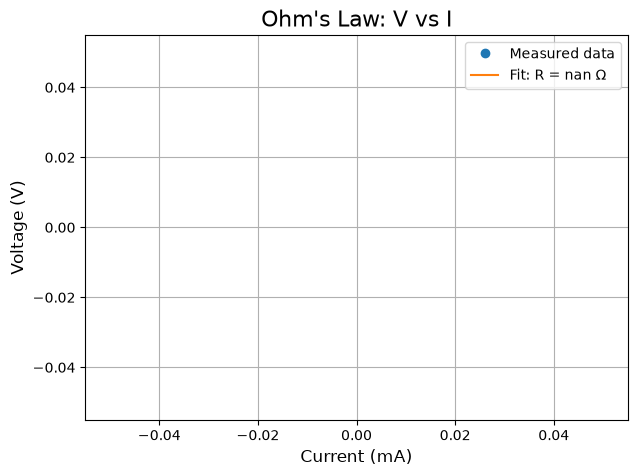

In [31]:
# Linear regression: V = I*R  ->  slope = R
fit = linregress(I_measured, V_measured)
R_fit = fit.slope

print(f"Measured R (from fit slope): {R_fit:.1f} Ω")
print(f"Nominal R: {R_nominal:.0f} Ω")
print(f"Difference: {abs(R_fit - R_nominal)/R_nominal*100:.2f}%")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(I_measured * 1000, V_measured, 'o', label='Measured data')
I_fit_line = np.linspace(0, I_measured.max(), 50) if len(I_measured) else np.array([0, 1])
ax.plot(I_fit_line * 1000, fit.slope * I_fit_line + fit.intercept, '-', label=f'Fit: R = {R_fit:.0f} Ω')
look_nice(ax, "Current (mA)", "Voltage (V)", "Ohm's Law: V vs I")
plt.show()

## 1L.3   Voltage divider

### Textbook questions
- No questions found in the textbook, rather general lab advice.

### Lecture questions
1. When doing this experiment, should you use the nominal or measured values of the resistance? Why?
2. Discuss the text at the top of page 30 (shown below) with your instructor before wiring it.

### Instructions
1. Construct the voltage divider (Circuit 2): R1 = 15k, R2 = 15k, $V_{in} = 15V$.
2. Measure the **open-circuit** output voltage → record as $V_{output}$.
   - Expected: $V_{output} = V_{in} \cdot \frac{R_2}{R_1+R_2} \approx 7.5\text{V}$
---
3. Attach the 7.5k load (Circuit 3) and observe/record the loaded output voltage.
4. Measure the **short-circuit current**: short the output to ground, routing the current *through the ammeter* (don't bypass it) → record as $I_{short\ circuit}$.
   - Expected: $I_{sc} = \frac{V_{in}}{R_1} \approx 1\text{mA}$
   - Check the DVM's ammeter current range before shorting — avoid tripping the internal fuse.
---
5. Calculate the Thevenin equivalent:
   - $R_{Thev} = \dfrac{V_{output}}{I_{short\ circuit}}$
   - Expected: $R_{Thev} \approx 7.5\text{k}\Omega$ (matches $R_1 \parallel R_2$)
---
6. Build the Thevenin equivalent circuit (7.5V source + 7.5kΩ series resistor) and reattach the 7.5k load — confirm it reproduces the loaded output voltage from step 3.

### Circuit diagrams
<p align="left">
  <img src="lab1_circuit2.png" alt="Circuit 2 Diagram" width="340" height="308"><br>
  <b>Circuit 2</b>
</p>
<p align="left">
  <img src="lab1_circuit3.png" alt="Circuit 3 Diagram" width="340" height="308"><br>
  <b>Circuit 3</b>
</p>